# Student Lifestyle & Academic Performance - Exploratory Data Analysis

## Objective

This notebook performs an exploratory data analysis (EDA) on a dataset examining the relationship between student lifestyle factors and academic performance. The analysis aims to:

- Understand the structure and characteristics of the dataset
- Explore relationships between lifestyle variables (study hours, sleep, physical activity, social time, extracurricular activities) and academic performance (GPA)
- Analyze stress levels across different student profiles
- Identify patterns and insights that could inform recommendations for students

**Dataset:** `data/student_lifestyle_dataset.csv`

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## Data Understanding

### Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/student_lifestyle_dataset.csv')

# Display the dataset shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 2000 rows, 8 columns


### First 5 Rows

In [3]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


### Last 5 Rows

In [4]:
df.tail()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
1995,1996,6.5,0.2,7.4,2.1,7.8,3.32,Moderate
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High
1999,2000,9.0,1.7,7.3,3.1,2.9,3.58,High


### Dataset Shape

In [5]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 2000
Number of columns: 8


### Dataset Info (Data Types and Non-Null Counts)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   str    
dtypes: float64(6), int64(1), str(1)
memory usage: 125.1 KB


### Descriptive Statistics for Numerical Columns

In [7]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


### Categorical Column Analysis: Stress_Level

In [8]:
# Display unique values for Stress_Level
print("Unique values in Stress_Level:")
print(df['Stress_Level'].unique())
print()

# Display value counts for Stress_Level
print("Value counts for Stress_Level:")
print(df['Stress_Level'].value_counts())
print()

# Display percentage distribution
print("Percentage distribution for Stress_Level:")
print(df['Stress_Level'].value_counts(normalize=True) * 100)

Unique values in Stress_Level:
<StringArray>
['Moderate', 'Low', 'High']
Length: 3, dtype: str

Value counts for Stress_Level:
Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64

Percentage distribution for Stress_Level:
Stress_Level
High        51.45
Moderate    33.70
Low         14.85
Name: proportion, dtype: float64


### Column Classification

In [9]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)
print()

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)
print()

# Identify identifier columns
identifier_cols = []
for col in df.columns:
    if 'id' in col.lower() or df[col].nunique() == len(df):
        identifier_cols.append(col)

print(f"Identifier columns ({len(identifier_cols)}):")
print(identifier_cols)

Numerical columns (7):
['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']

Categorical columns (1):
['Stress_Level']

Identifier columns (1):
['Student_ID']


# 10. Data Cleaning

Data cleaning is performed to identify and address data-quality issues before conducting exploratory analysis.

The following checks are performed:

- Missing values
- Duplicate rows
- Duplicate Student_ID values
- Stress_Level category consistency
- Data types
- Invalid or impossible numerical values
- GPA range validation
- Negative values in daily-hour variables

The original dataset is preserved and is not modified.

In [10]:
# Step 10: Data Quality Checks

print("DATA CLEANING / QUALITY CHECKS")
print("=" * 50)

# 1. Missing values
print("\n1. Missing Values")
missing_values = df.isnull().sum()
print(missing_values)

# 2. Duplicate rows
duplicate_rows = df.duplicated().sum()
print("\n2. Duplicate Rows:", duplicate_rows)

# 3. Duplicate Student_ID
duplicate_student_ids = df['Student_ID'].duplicated().sum()
print("3. Duplicate Student_IDs:", duplicate_student_ids)

# 4. Stress_Level values
print("\n4. Stress_Level Categories")
print(df['Stress_Level'].value_counts(dropna=False))

# 5. Data types
print("\n5. Data Types")
print(df.dtypes)

# 6. Numerical columns excluding Student_ID
analysis_numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != 'Student_ID'
]

# 7. Negative values
print("\n6. Negative Values in Numerical Analysis Variables")
for col in analysis_numeric_cols:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count}")

# 8. GPA validation
print("\n7. GPA Validation")
print("Minimum GPA:", df['GPA'].min())
print("Maximum GPA:", df['GPA'].max())
print("GPA values outside 0-4:", ((df['GPA'] < 0) | (df['GPA'] > 4)).sum())

# 9. Summary
print("\nDATA QUALITY CHECK COMPLETE")

DATA CLEANING / QUALITY CHECKS

1. Missing Values
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

2. Duplicate Rows: 0
3. Duplicate Student_IDs: 0

4. Stress_Level Categories
Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64

5. Data Types
Student_ID                           int64
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                           str
dtype: object

6. Negative Values in Numerical Analysis Variables
Study_Hours_Per_Day: 0
Extracurricular_Hours_Per

### Data Cleaning Decision

The data-quality checks were performed before analysis. Missing values, duplicate records, duplicate Student_ID values, category consistency, numerical ranges, and data types were examined.

No observation should be removed solely because it is statistically unusual. Any potential outliers will be investigated separately during the formal Outlier Analysis stage.

The original dataset remains unchanged.

# 11. Cleaned Dataset Validation

After the data-quality checks, the dataset is validated to ensure that it is suitable for subsequent exploratory analysis.

The validation confirms the dataset structure, data types, uniqueness of Student_ID, validity of Stress_Level categories, GPA range, and non-negative lifestyle-hour values.

In [11]:
# Step 11: Dataset Validation

print("CLEANED DATASET VALIDATION")
print("=" * 50)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Student_IDs:")
print(df['Student_ID'].duplicated().sum())

print("\nStress_Level Categories:")
print(df['Stress_Level'].unique())

print("\nData Types:")
print(df.dtypes)

print("\nGPA Range:")
print(f"Minimum: {df['GPA'].min()}")
print(f"Maximum: {df['GPA'].max()}")

print("\nNegative Values:")
for col in analysis_numeric_cols:
    print(f"{col}: {(df[col] < 0).sum()}")

print("\nValidation completed.")

CLEANED DATASET VALIDATION

Dataset Shape:
(2000, 8)

Column Names:
['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level']

Missing Values:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

Duplicate Rows:
0

Duplicate Student_IDs:
0

Stress_Level Categories:
<StringArray>
['Moderate', 'Low', 'High']
Length: 3, dtype: str

Data Types:
Student_ID                           int64
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                     

# 12. Analysis Variables

For exploratory analysis, the variables are divided into three roles.

### Identifier

`Student_ID` is retained only for identifying individual records. It is not used in statistical analysis, correlations, or analytical visualizations.

### Numerical Analysis Variables

The lifestyle and academic numerical variables are used for descriptive, bivariate, multivariate, and outlier analysis.

### Categorical Analysis Variable

`Stress_Level` is treated as a categorical variable with ordered categories such as Low, Moderate, and High.

In [12]:
# Step 12: Define Analysis Variables

identifier_cols = ['Student_ID']

numerical_analysis_cols = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day',
    'GPA'
]

categorical_analysis_cols = ['Stress_Level']

print("Identifier columns:")
print(identifier_cols)

print("\nNumerical analysis columns:")
print(numerical_analysis_cols)

print("\nCategorical analysis columns:")
print(categorical_analysis_cols)

print("\nStudent_ID excluded from numerical analysis:",
      'Student_ID' not in numerical_analysis_cols)

Identifier columns:
['Student_ID']

Numerical analysis columns:
['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']

Categorical analysis columns:
['Stress_Level']

Student_ID excluded from numerical analysis: True


# 13. Univariate Analysis – Numerical Variables

Univariate analysis examines one variable at a time.

For each numerical analysis variable, descriptive statistics and distribution visualizations are used to understand central tendency, variability, distribution shape, and potentially unusual observations.

Student_ID is excluded because it is an identifier rather than a meaningful analytical variable.

In [13]:
# Step 13: Descriptive Statistics

numerical_summary = df[numerical_analysis_cols].describe().T

numerical_summary['median'] = df[numerical_analysis_cols].median()
numerical_summary['skewness'] = df[numerical_analysis_cols].skew()

numerical_summary = numerical_summary[
    ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness']
]

display(numerical_summary.round(3))

,count,mean,median,std,min,25%,50%,75%,max,skewness
Study_Hours_Per_Day,2000.0,7.476,7.40,1.424,5.00,6.3,7.40,8.70,10.0,0.035
Extracurricular_Hours_Per_Day,2000.0,1.990,2.00,1.156,0.00,1.0,2.00,3.00,4.0,0.001
Sleep_Hours_Per_Day,2000.0,7.501,7.50,1.461,5.00,6.2,7.50,8.80,10.0,-0.007
Social_Hours_Per_Day,2000.0,2.705,2.60,1.689,0.00,1.2,2.60,4.10,6.0,0.184
Physical_Activity_Hours_Per_Day,2000.0,4.328,4.10,2.514,0.00,2.4,4.10,6.10,13.0,0.399
GPA,2000.0,3.116,3.11,0.299,2.24,2.9,3.11,3.33,4.0,0.028


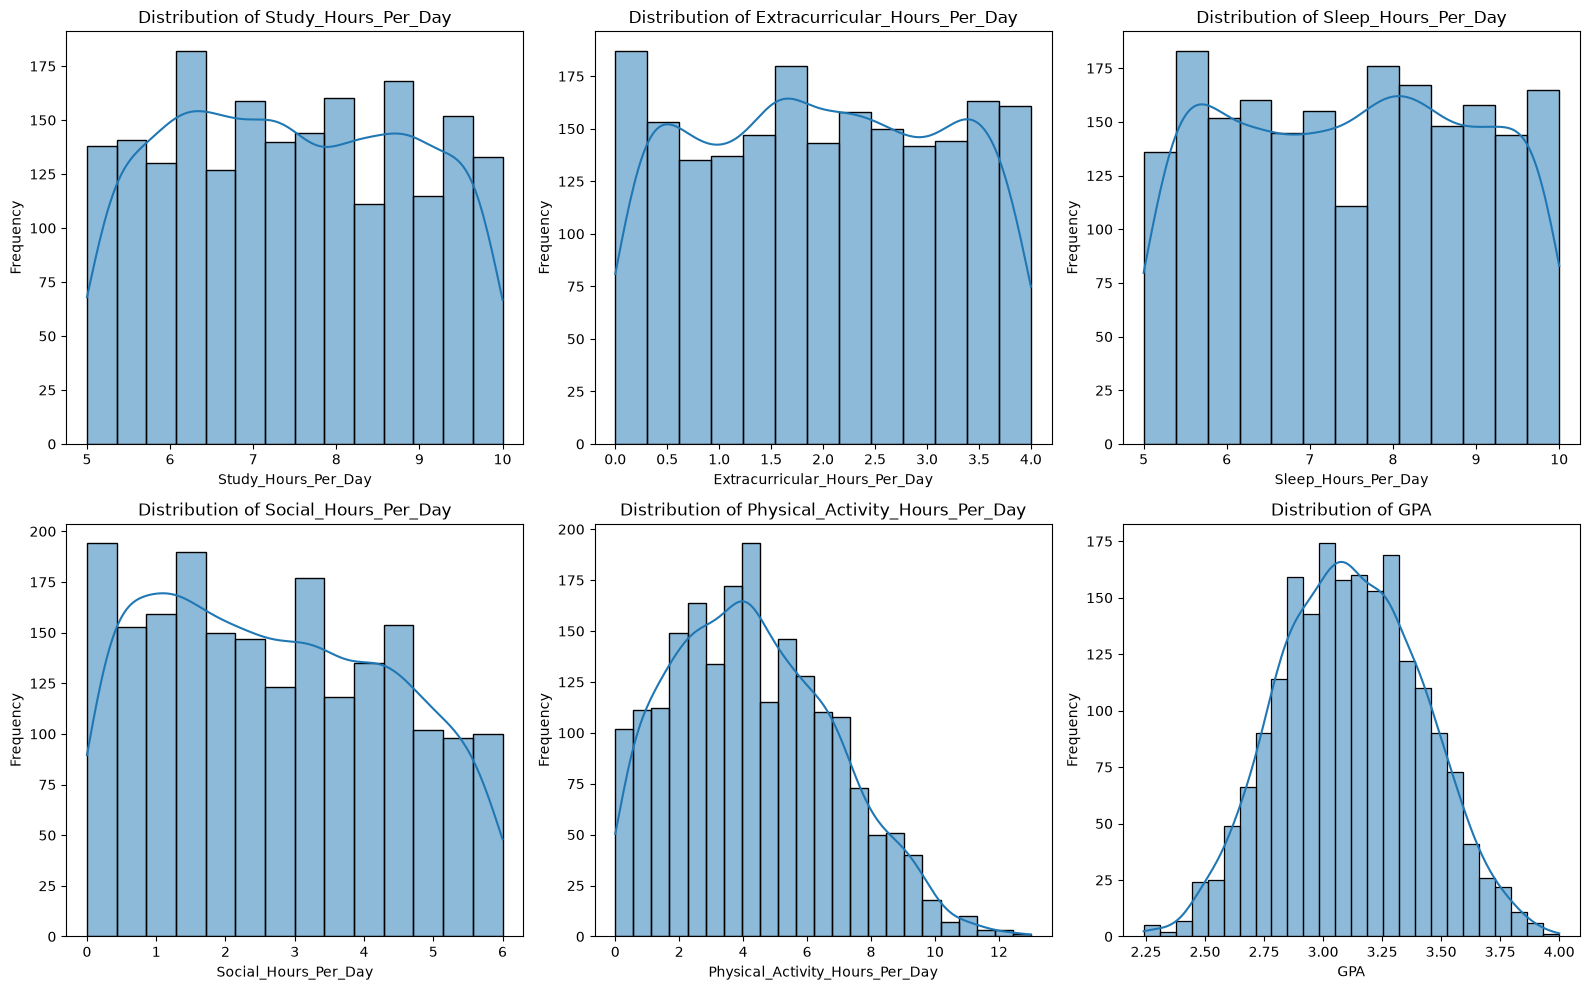

In [14]:
# Histograms for numerical analysis variables

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_analysis_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

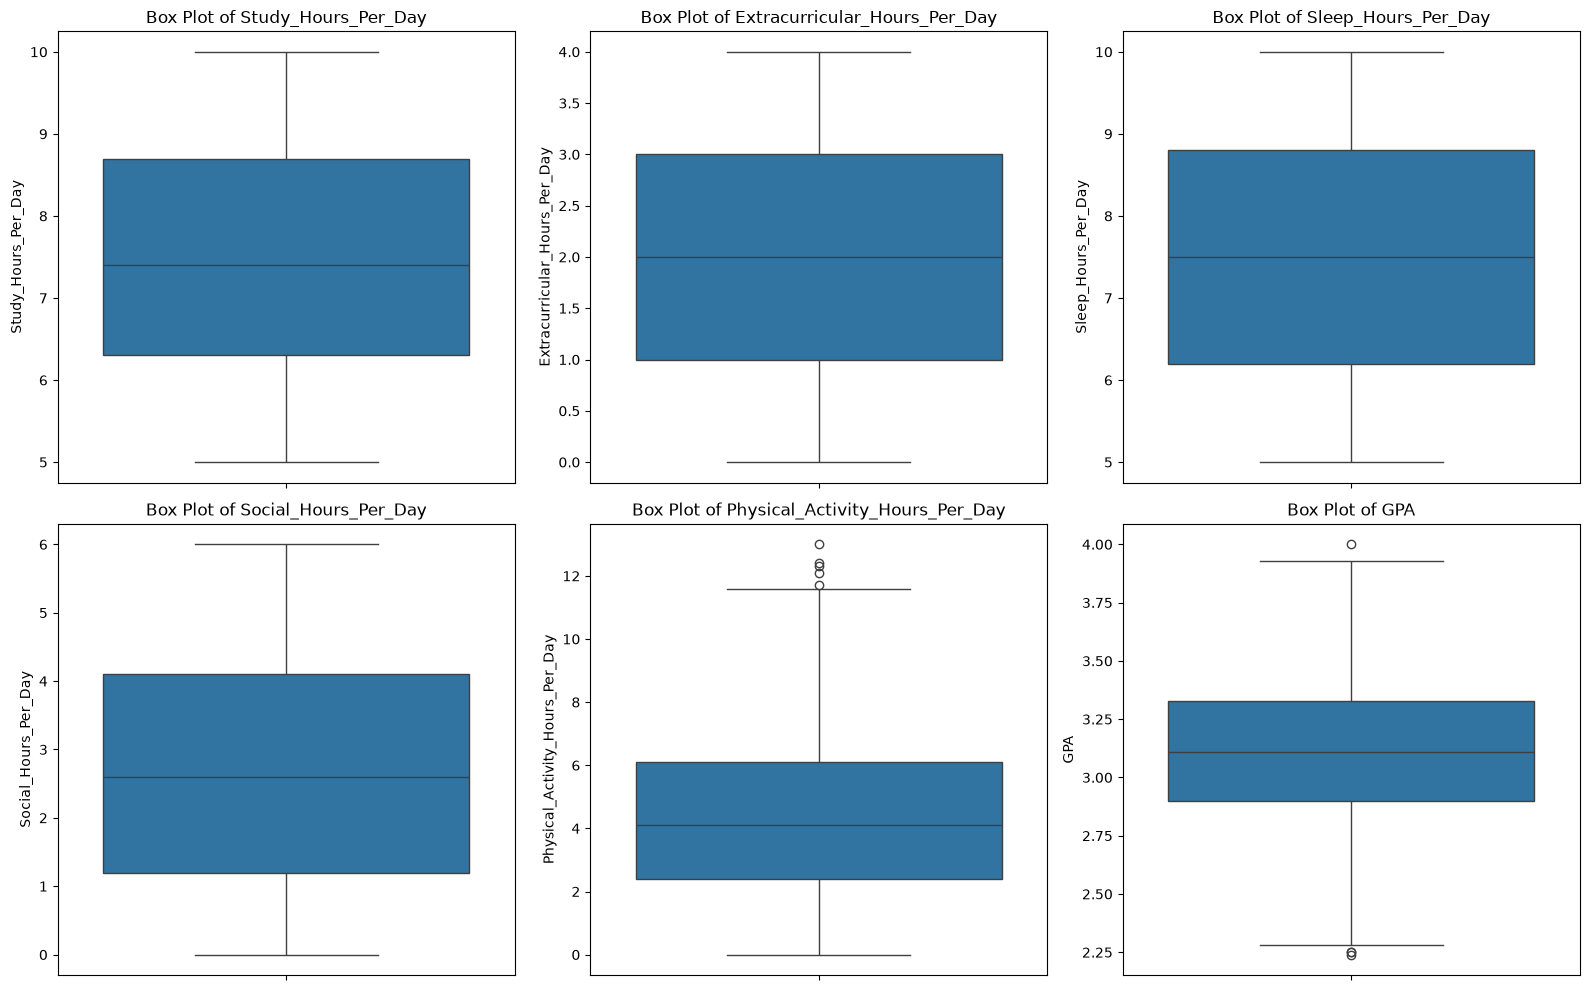

In [15]:
# Box plots for numerical analysis variables

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_analysis_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# 14. Univariate Analysis – Stress Level

Stress_Level is the main categorical variable in the dataset.

Its frequency and percentage distribution are examined to understand how students are distributed across Low, Moderate, and High stress categories.

In [16]:
# Step 14: Stress Level Distribution

stress_counts = df['Stress_Level'].value_counts()

stress_percentages = (
    df['Stress_Level']
    .value_counts(normalize=True)
    .mul(100)
)

stress_summary = pd.DataFrame({
    'Count': stress_counts,
    'Percentage': stress_percentages
})

# Preserve logical order where these categories exist
stress_order = ['Low', 'Moderate', 'High']

stress_summary = stress_summary.reindex(
    [x for x in stress_order if x in stress_summary.index]
)

display(stress_summary.round(2))

,Count,Percentage
Stress_Level,,
Low,297,14.85
Moderate,674,33.70
High,1029,51.45


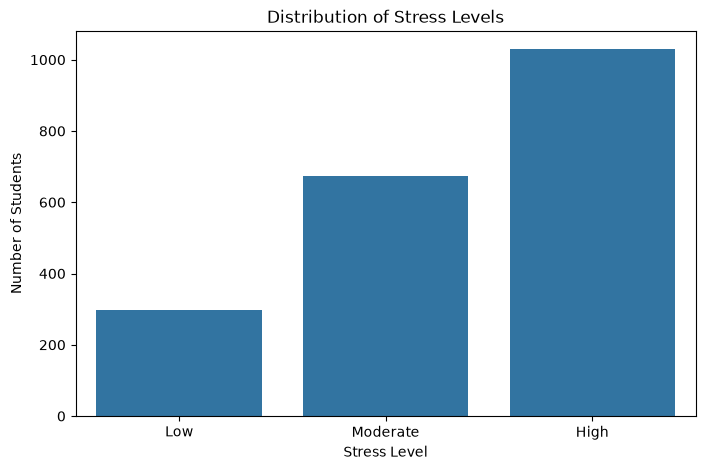

In [17]:
# Stress Level Bar Chart

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Stress_Level',
    order=stress_order
)

plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Number of Students')

plt.show()

# 15. Univariate Analysis – Key Findings

The numerical distributions provide an overview of students' lifestyle and academic characteristics, while the Stress_Level distribution shows how students are distributed across stress categories.

The descriptive statistics, histograms, and box plots should be used together to identify central tendencies, variation, distribution shapes, and observations that may require further investigation.

The Stress_Level distribution is interpreted using the observed counts and percentages rather than assuming that the categories are equally represented.

These findings describe the dataset but do not establish relationships between variables. Relationships are investigated in the following Bivariate Analysis stage.

# 16. Bivariate Analysis

Bivariate analysis examines the relationship between two variables at a time.

In this project, the analysis focuses on relationships between lifestyle variables, academic performance (GPA), and Stress_Level.

Student_ID is excluded from all relationship analysis because it is an identifier and does not represent a meaningful student characteristic.

## Part A: Lifestyle Variables vs GPA

The relationship between each lifestyle variable and GPA is examined using Pearson correlation and scatter plots.

The lifestyle variables considered are:

- Study_Hours_Per_Day
- Extracurricular_Hours_Per_Day
- Sleep_Hours_Per_Day
- Social_Hours_Per_Day
- Physical_Activity_Hours_Per_Day

Correlation measures the direction and strength of a linear association. It does not establish causation.

In [18]:
# Step 16A: Lifestyle Variables vs GPA

from scipy.stats import pearsonr

lifestyle_cols = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]

gpa_results = []

for col in lifestyle_cols:
    temp = df[[col, 'GPA']].dropna()

    r, p = pearsonr(temp[col], temp['GPA'])

    # Direction
    if r > 0:
        direction = "Positive"
    elif r < 0:
        direction = "Negative"
    else:
        direction = "No linear association"

    # Approximate strength
    abs_r = abs(r)

    if abs_r < 0.20:
        strength = "Very weak"
    elif abs_r < 0.40:
        strength = "Weak"
    elif abs_r < 0.60:
        strength = "Moderate"
    elif abs_r < 0.80:
        strength = "Strong"
    else:
        strength = "Very strong"

    significance = (
        "Statistically significant"
        if p < 0.05
        else "Not statistically significant"
    )

    gpa_results.append({
        'Lifestyle Variable': col,
        'Pearson r': r,
        'p-value': p,
        'Direction': direction,
        'Strength': strength,
        'Significance': significance
    })

gpa_correlation_results = pd.DataFrame(gpa_results)

display(gpa_correlation_results.round(4))

,Lifestyle Variable,Pearson r,p-value,Direction,Strength,Significance
0,Study_Hours_Per_Day,0.7345,0.0000,Positive,Strong,Statistically significant
1,Extracurricular_Hours_Per_Day,-0.0322,0.1503,Negative,Very weak,Not statistically significant
2,Sleep_Hours_Per_Day,-0.0043,0.8484,Negative,Very weak,Not statistically significant
3,Social_Hours_Per_Day,-0.0857,0.0001,Negative,Very weak,Statistically significant
4,Physical_Activity_Hours_Per_Day,-0.3412,0.0000,Negative,Weak,Statistically significant


In [19]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


### Interpretation of Lifestyle Variables vs GPA

The Pearson correlation analysis reveals different levels of association between lifestyle variables and GPA.

- **Study_Hours_Per_Day** has the strongest relationship with GPA, with a strong positive correlation (r = 0.7345, p < 0.001). Students reporting higher study hours tend to have higher GPA values in this dataset.

- **Physical_Activity_Hours_Per_Day** shows a weak negative association with GPA (r = -0.3412, p < 0.001). Although the relationship is statistically significant, its magnitude is considerably weaker than the relationship between study hours and GPA.

- **Social_Hours_Per_Day** shows a very weak negative association with GPA (r = -0.0857, p < 0.001). Despite statistical significance, the small correlation magnitude indicates that the linear association is weak.

- **Extracurricular_Hours_Per_Day** shows a very weak negative association with GPA (r = -0.0322, p = 0.1503), which is not statistically significant.

- **Sleep_Hours_Per_Day** shows almost no linear association with GPA (r = -0.0043, p = 0.8484) and is not statistically significant.

Overall, Study_Hours_Per_Day has the strongest observed linear association with GPA among the lifestyle variables examined.

These findings describe associations in the dataset and do not establish causal relationships. Statistical significance should also be considered alongside the magnitude of the correlation.

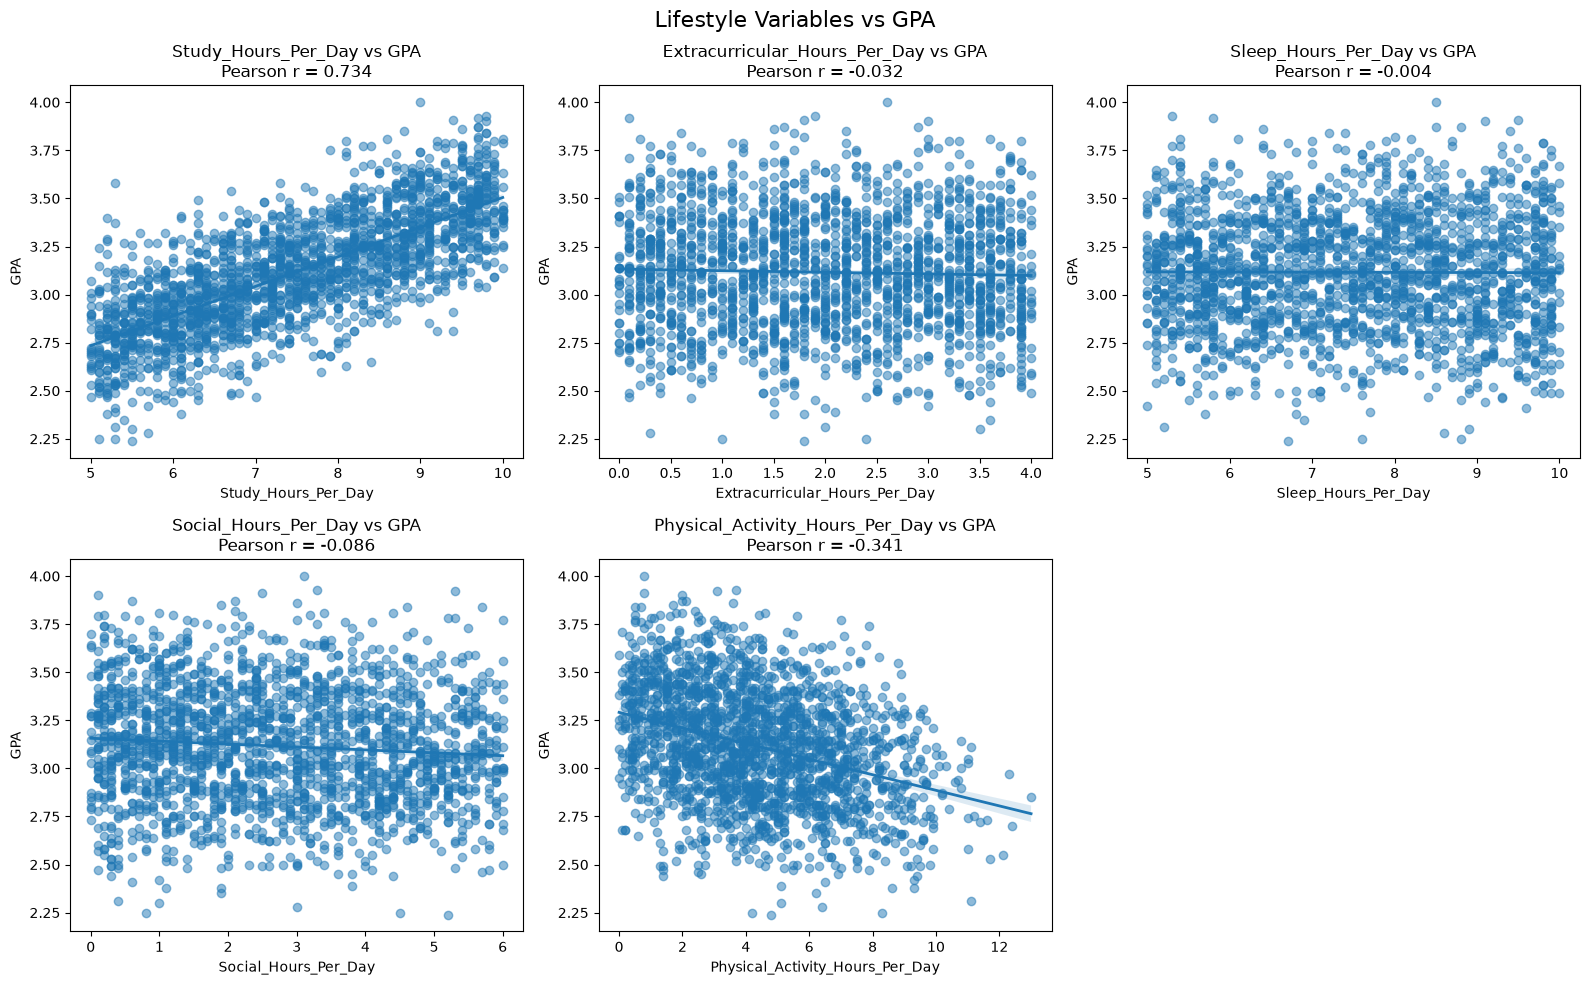

In [20]:
# Step 16A: Scatter Plots of Lifestyle Variables vs GPA

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(lifestyle_cols):

    sns.regplot(
        data=df,
        x=col,
        y='GPA',
        scatter_kws={'alpha': 0.5},
        line_kws={'linewidth': 2},
        ax=axes[i]
    )

    r = gpa_correlation_results.loc[
        gpa_correlation_results['Lifestyle Variable'] == col,
        'Pearson r'
    ].iloc[0]

    axes[i].set_title(
        f'{col} vs GPA\nPearson r = {r:.3f}'
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('GPA')

# We have 5 variables, so hide the unused 6th plot
axes[-1].axis('off')

plt.suptitle(
    'Lifestyle Variables vs GPA',
    fontsize=16
)

plt.tight_layout()
plt.show()

### Part A Summary: Lifestyle Variables vs GPA

The bivariate analysis shows that Study_Hours_Per_Day has the strongest association with GPA among the lifestyle variables examined. The scatter plot shows a clear upward trend, consistent with the strong positive Pearson correlation (r = 0.7345, p < 0.001).

Physical_Activity_Hours_Per_Day shows a weaker negative association with GPA (r = -0.3412, p < 0.001), which is visible as a downward trend in the scatter plot.

Social_Hours_Per_Day has a very weak negative association with GPA (r = -0.0857, p < 0.001). Although statistically significant, the magnitude of this relationship is small.

Extracurricular_Hours_Per_Day and Sleep_Hours_Per_Day show negligible linear associations with GPA and are not statistically significant.

Overall, the scatter plots support the numerical correlation results. However, these relationships represent associations within the observed dataset and should not be interpreted as evidence of causation.

## Part B: Lifestyle Variables vs Stress Level

This section examines whether lifestyle variables differ across the Low, Moderate, and High Stress_Level categories.

Stress_Level is treated as a categorical variable rather than assigning arbitrary numerical values to the categories.

For each lifestyle variable, group-level means and medians are calculated for the three stress categories. The Kruskal-Wallis test is used to assess whether there is evidence of a statistically significant difference among the groups.

Box plots are used to visualize the distribution of each lifestyle variable across stress levels.

Statistical significance indicates evidence of group differences, but it does not establish causation.

In [21]:
# Step 16B: Lifestyle Variables vs Stress Level

from scipy.stats import kruskal

stress_order = ['Low', 'Moderate', 'High']

stress_results = []

for col in lifestyle_cols:

    groups = [
        df.loc[df['Stress_Level'] == level, col].dropna()
        for level in stress_order
    ]

    # Kruskal-Wallis test
    h_stat, p_value = kruskal(*groups)

    stress_results.append({
        'Lifestyle Variable': col,

        'Low Mean': groups[0].mean(),
        'Moderate Mean': groups[1].mean(),
        'High Mean': groups[2].mean(),

        'Low Median': groups[0].median(),
        'Moderate Median': groups[1].median(),
        'High Median': groups[2].median(),

        'Kruskal-Wallis H': h_stat,
        'p-value': p_value,

        'Significant (p < 0.05)': (
            'Yes' if p_value < 0.05 else 'No'
        )
    })

stress_comparison_results = pd.DataFrame(stress_results)

display(stress_comparison_results.round(4))

,Lifestyle Variable,Low Mean,Moderate Mean,High Mean,Low Median,Moderate Median,High Median,Kruskal-Wallis H,p-value,Significant (p < 0.05)
0,Study_Hours_Per_Day,5.4744,6.9696,8.3850,5.5,7.00,8.7,1093.4757,0.0000,Yes
1,Extracurricular_Hours_Per_Day,1.9889,2.0064,1.9798,2.0,2.00,2.0,0.2152,0.8980,No
2,Sleep_Hours_Per_Day,8.0640,7.9476,7.0465,8.0,7.90,6.8,205.7265,0.0000,Yes
3,Social_Hours_Per_Day,2.8909,2.7396,2.6278,3.0,2.60,2.4,6.2574,0.0438,Yes
4,Physical_Activity_Hours_Per_Day,5.5818,4.3368,3.9609,5.3,4.25,3.6,104.1726,0.0000,Yes


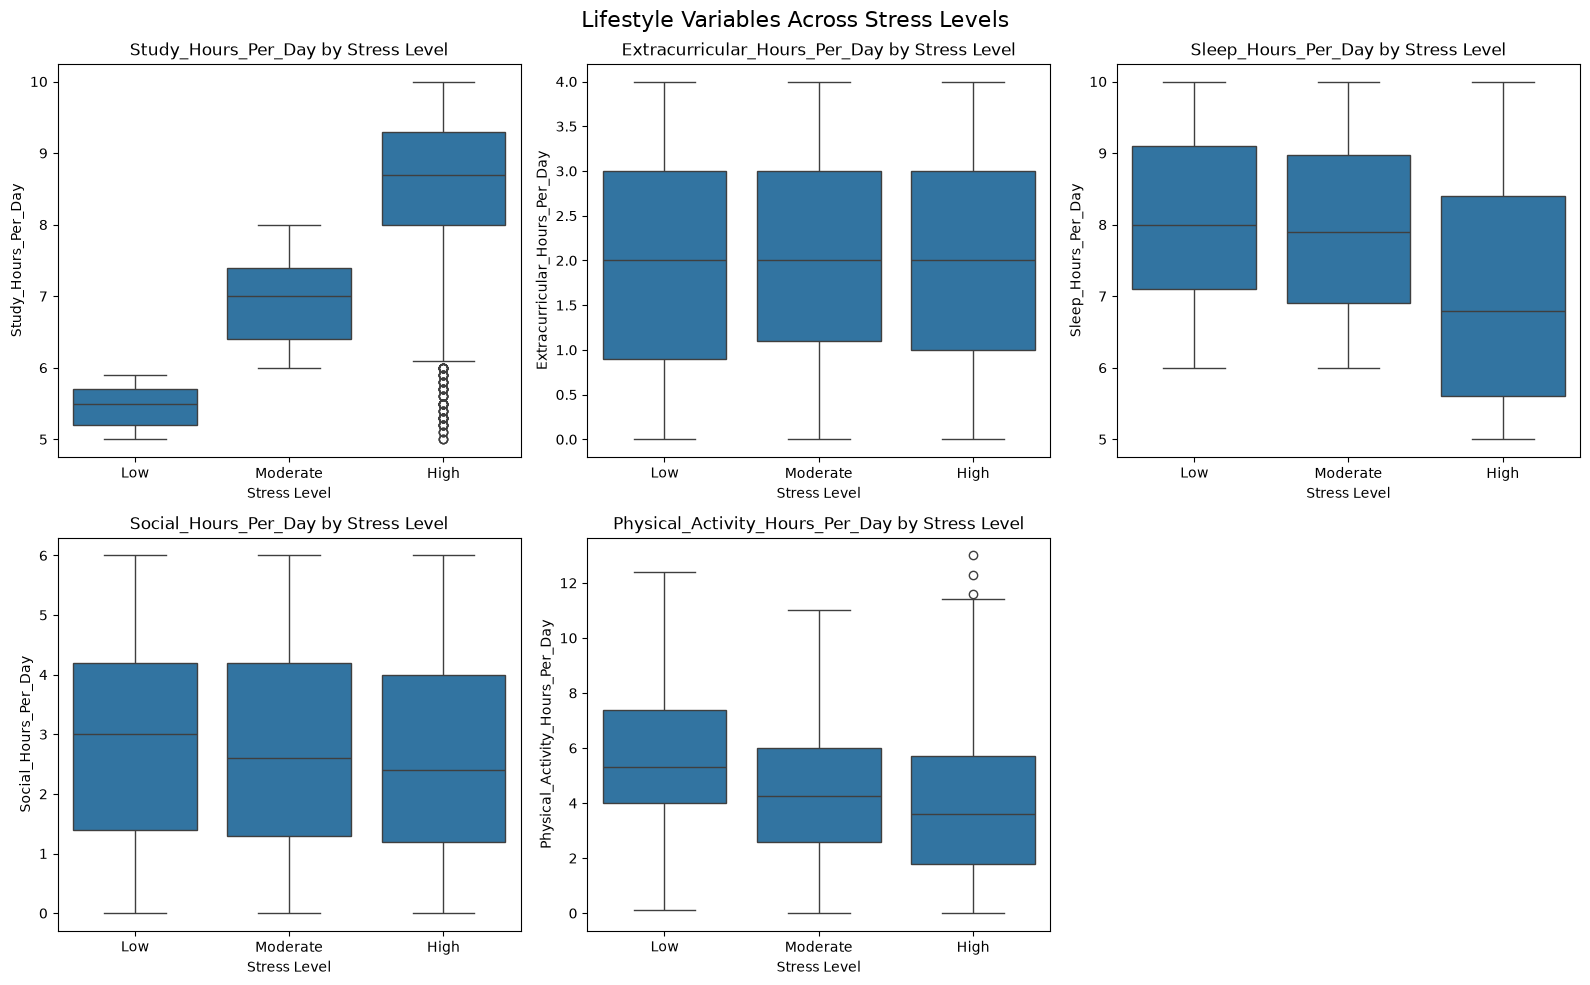

In [22]:
# Step 16B: Box Plots of Lifestyle Variables Across Stress Levels

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(lifestyle_cols):

    sns.boxplot(
        data=df,
        x='Stress_Level',
        y=col,
        order=stress_order,
        ax=axes[i]
    )

    axes[i].set_title(
        f'{col} by Stress Level'
    )

    axes[i].set_xlabel('Stress Level')
    axes[i].set_ylabel(col)

# Hide unused sixth subplot
axes[-1].axis('off')

plt.suptitle(
    'Lifestyle Variables Across Stress Levels',
    fontsize=16
)

plt.tight_layout()
plt.show()

### Interpretation of Lifestyle Variables vs Stress Level

The comparison of lifestyle variables across Stress_Level categories reveals several notable patterns.

**Study_Hours_Per_Day** shows the clearest difference across stress groups. The mean study hours increase from 5.4744 hours for Low stress to 6.9696 hours for Moderate stress and 8.3850 hours for High stress. The Kruskal-Wallis test indicates a statistically significant difference among the groups (H = 1093.4757, p < 0.001).

**Sleep_Hours_Per_Day** shows the opposite pattern. Mean sleep decreases from 8.0640 hours for Low stress to 7.9476 hours for Moderate stress and 7.0465 hours for High stress. The group difference is statistically significant (H = 205.7265, p < 0.001).

**Physical_Activity_Hours_Per_Day** also decreases as stress level increases. The mean decreases from 5.5818 hours for Low stress to 4.3368 hours for Moderate stress and 3.9609 hours for High stress. The Kruskal-Wallis test indicates a statistically significant difference among the groups (H = 104.1713, p < 0.001).

**Social_Hours_Per_Day** shows a smaller decreasing pattern, with means of 2.8909, 2.7396, and 2.6278 hours for Low, Moderate, and High stress respectively. The difference is statistically significant, although the magnitude of the group difference is relatively small (H = 6.2574, p < 0.05).

**Extracurricular_Hours_Per_Day** shows almost identical values across the three stress groups, with means of 1.9889, 2.0064, and 1.9798 hours. The Kruskal-Wallis test is not statistically significant (H = 0.2152, p = 0.89), indicating no evidence of a meaningful difference among the stress groups.

Overall, the analysis suggests that study time, sleep, physical activity, and social hours differ across stress categories, whereas extracurricular hours do not show a statistically significant difference.

These findings represent associations and group differences in the observed dataset. They should not be interpreted as evidence that any particular lifestyle factor directly causes a change in stress level.

## Part C: GPA vs Stress Level

This section examines the relationship between academic performance (GPA) and Stress_Level.

GPA is a numerical variable, while Stress_Level is a categorical variable with Low, Moderate, and High categories.

The analysis compares GPA distributions across the three stress groups using descriptive statistics and a box plot. The Kruskal-Wallis test is used to determine whether there is evidence of a statistically significant difference in GPA across the stress categories.

This analysis identifies group differences and does not establish a causal relationship between stress and GPA.

In [23]:
# Step 16C: GPA by Stress Level

gpa_stress_groups = (
    df.groupby('Stress_Level')['GPA']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reindex(stress_order)
)

display(gpa_stress_groups.round(4))

,count,mean,median,std,min,max
Stress_Level,,,,,,
Low,297,2.8169,2.82,0.2154,2.24,3.58
Moderate,674,3.0248,3.02,0.2207,2.44,3.75
High,1029,3.2620,3.27,0.2750,2.31,4.00


In [24]:
# Kruskal-Wallis test: GPA across Stress Levels

gpa_groups = [
    df.loc[df['Stress_Level'] == level, 'GPA'].dropna()
    for level in stress_order
]

gpa_h_stat, gpa_p_value = kruskal(*gpa_groups)

print("Kruskal-Wallis Test: GPA vs Stress Level")
print("-" * 50)
print(f"H-statistic: {gpa_h_stat:.4f}")
print(f"p-value: {gpa_p_value:.6f}")

if gpa_p_value < 0.05:
    print("Result: Statistically significant difference")
else:
    print("Result: Not statistically significant")

Kruskal-Wallis Test: GPA vs Stress Level
--------------------------------------------------
H-statistic: 620.6702
p-value: 0.000000
Result: Statistically significant difference


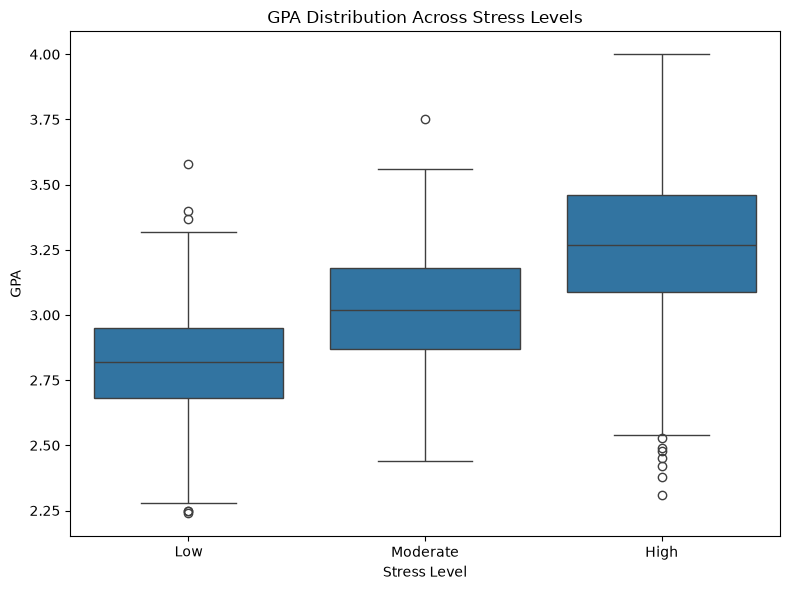

In [25]:
# Box Plot: GPA Across Stress Levels

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Stress_Level',
    y='GPA',
    order=stress_order
)

plt.title('GPA Distribution Across Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('GPA')

plt.tight_layout()
plt.show()

### Interpretation of GPA vs Stress Level

The descriptive analysis shows a clear difference in GPA distributions across the three stress categories.

Students in the Low stress group have a mean GPA of 2.8169, while students in the Moderate stress group have a mean GPA of 3.0248. The High stress group has the highest mean GPA at 3.2620. The median GPA follows the same pattern, increasing from 2.82 for Low stress to 3.02 for Moderate stress and 3.27 for High stress.

The Kruskal-Wallis test indicates that the differences in GPA distributions across the three stress groups are statistically significant (H = 620.6702, p < 0.001).

The box plot also shows the upward shift in the GPA distribution from Low to High stress levels. Therefore, in this dataset, Stress_Level is associated with differences in GPA, with the High stress group having the highest observed GPA distribution.

However, this result should not be interpreted as evidence that higher stress causes higher GPA. The analysis identifies an association between the variables and does not establish causation. Other factors may contribute to the observed pattern.

## Bivariate Analysis — Overall Summary

The bivariate analysis examined relationships between lifestyle variables, GPA, and Stress_Level.

### Key Findings

1. **Lifestyle Variables vs GPA**

   Study_Hours_Per_Day showed the strongest positive association with GPA (r = 0.7345, p < 0.001). Physical_Activity_Hours_Per_Day showed a weaker negative association with GPA (r = -0.3412, p < 0.001). Social_Hours_Per_Day showed a very weak negative association (r = -0.0857, p < 0.001), while Extracurricular_Hours_Per_Day and Sleep_Hours_Per_Day did not show statistically significant linear associations with GPA.

2. **Lifestyle Variables vs Stress Level**

   The Kruskal-Wallis analysis indicated statistically significant differences across stress groups for Study_Hours_Per_Day, Sleep_Hours_Per_Day, Social_Hours_Per_Day, and Physical_Activity_Hours_Per_Day. Study hours increased substantially from the Low stress group to the High stress group, while sleep hours and physical activity hours decreased. Extracurricular_Hours_Per_Day did not show a statistically significant difference across stress groups.

3. **GPA vs Stress Level**

   GPA differed significantly across Stress_Level categories (H = 620.6702, p < 0.001). Mean GPA increased from 2.8169 for Low stress students to 3.0248 for Moderate stress students and 3.2620 for High stress students.

### Overall Bivariate Insight

The bivariate analysis reveals several notable associations among academic performance, lifestyle behavior, and stress level. Study hours have the strongest observed relationship with GPA, while study time, sleep, social activity, and physical activity also differ across stress categories.

An important observation is that the High stress group has both higher study hours and higher GPA in this dataset. This does not imply that stress causes better academic performance. Similarly, the observed relationships between lifestyle variables and stress should not be interpreted as causal relationships.

These bivariate findings provide a foundation for the next stage of analysis, where multiple variables will be examined together to better understand their combined relationships and patterns.

## 17. Multivariate Analysis

Multivariate analysis examines relationships among multiple numerical variables simultaneously. This stage extends the earlier bivariate analysis by considering the overall correlation structure among lifestyle variables and academic performance.

Student_ID is excluded because it is an identifier and does not represent a meaningful analytical variable.

The analysis variables considered are Study_Hours_Per_Day, Extracurricular_Hours_Per_Day, Sleep_Hours_Per_Day, Social_Hours_Per_Day, Physical_Activity_Hours_Per_Day, and GPA.

The first step is to construct a Pearson correlation matrix to examine the direction and strength of linear relationships among these variables.

In [26]:
# Step 17A: Multivariate Pearson Correlation Matrix

multivariate_cols = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day',
    'GPA'
]

correlation_matrix = df[multivariate_cols].corr(method='pearson')

display(correlation_matrix.round(4))

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
Study_Hours_Per_Day,1.0000,-0.0026,0.0267,-0.1378,-0.4881,0.7345
Extracurricular_Hours_Per_Day,-0.0026,1.0000,0.0088,-0.1391,-0.3700,-0.0322
Sleep_Hours_Per_Day,0.0267,0.0088,1.0000,-0.1936,-0.4703,-0.0043
Social_Hours_Per_Day,-0.1378,-0.1391,-0.1936,1.0000,-0.4171,-0.0857
Physical_Activity_Hours_Per_Day,-0.4881,-0.3700,-0.4703,-0.4171,1.0000,-0.3412
GPA,0.7345,-0.0322,-0.0043,-0.0857,-0.3412,1.0000


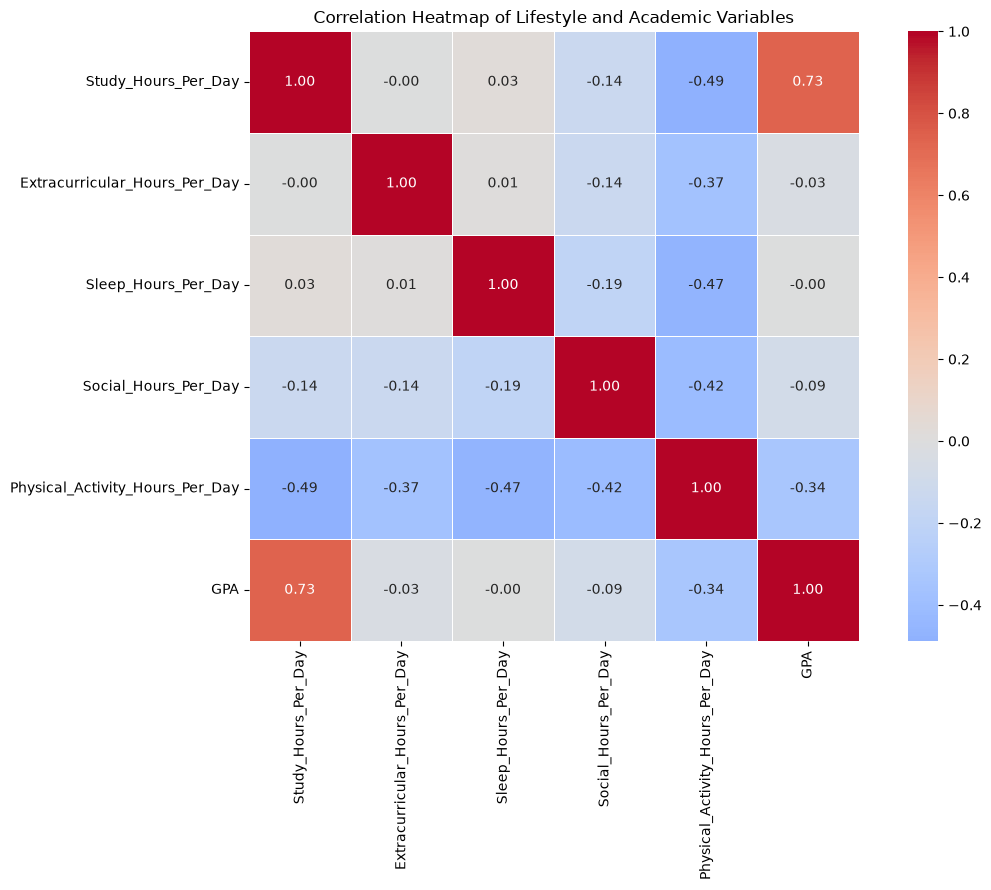

In [27]:
# Step 17B: Multivariate Correlation Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Lifestyle and Academic Variables')
plt.tight_layout()
plt.show()

### Multivariate Correlation Findings

The correlation matrix and heatmap provide an overall view of the linear relationships among the six numerical analysis variables.

The strongest positive relationship is between **Study_Hours_Per_Day and GPA** (r = 0.7345), indicating a strong positive association. This confirms the finding observed during the bivariate analysis.

The strongest negative relationship is between **Study_Hours_Per_Day and Physical_Activity_Hours_Per_Day** (r = -0.4881). This represents a moderate negative association, meaning that students reporting more study hours tend to report fewer physical activity hours in this dataset.

Other moderate negative associations are observed between Physical_Activity_Hours_Per_Day and Sleep_Hours_Per_Day (r = -0.4703), Physical_Activity_Hours_Per_Day and Social_Hours_Per_Day (r = -0.4171), and Physical_Activity_Hours_Per_Day and Extracurricular_Hours_Per_Day (r = -0.3700).

The relationships between GPA and most lifestyle variables are relatively weak except for Study_Hours_Per_Day. GPA has a weak negative association with Physical_Activity_Hours_Per_Day (r = -0.3412), while its relationships with Extracurricular_Hours_Per_Day (r = -0.0322), Sleep_Hours_Per_Day (r = -0.0043), and Social_Hours_Per_Day (r = -0.0857) are very weak.

Overall, the multivariate correlation structure suggests that study time is the variable most strongly associated with GPA, while physical activity has moderate negative associations with several other lifestyle variables.

Correlation does not imply causation. These results describe linear associations within the observed dataset and should not be interpreted as evidence that one variable directly causes changes in another.

### Multivariate Analysis — Summary

The multivariate correlation analysis provides a consolidated view of the relationships among lifestyle behaviors and academic performance.

The key finding is the strong positive association between Study_Hours_Per_Day and GPA (r = 0.7345). Physical_Activity_Hours_Per_Day shows moderate negative associations with Study_Hours_Per_Day, Sleep_Hours_Per_Day, Social_Hours_Per_Day, and Extracurricular_Hours_Per_Day.

Most other relationships are weak or negligible. In particular, Sleep_Hours_Per_Day, Social_Hours_Per_Day, and Extracurricular_Hours_Per_Day have very weak linear relationships with GPA.

The heatmap makes these patterns easier to identify and provides a useful overview of the correlation structure of the dataset.

These findings will be considered together with the earlier univariate and bivariate results when developing the final conclusions of the EDA.

# 18. Outlier Analysis

Outlier analysis is performed to identify observations that are unusually high or low compared with the overall distribution of the numerical variables.

Outliers are detected using the **Interquartile Range (IQR) method**. For each numerical variable, the first quartile (Q1), third quartile (Q3), and IQR are calculated.

The lower and upper boundaries are defined as:

- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Observations outside these boundaries are classified as potential outliers.

The analysis is performed only on the predefined numerical analysis variables. **Student_ID is excluded because it is an identifier and is not a meaningful analytical variable.**

Outliers will not be removed automatically. Their presence will first be evaluated to determine whether they represent genuine variation in student behavior or possible data-quality issues.

In [28]:
# Step 18A: Detect outliers using the IQR method

outlier_results = []

for col in numerical_analysis_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_results.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier Percentage': outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary.round(4))

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Study_Hours_Per_Day,6.3,8.70,2.40,2.700,12.300,0,0.00
1,Extracurricular_Hours_Per_Day,1.0,3.00,2.00,-2.000,6.000,0,0.00
2,Sleep_Hours_Per_Day,6.2,8.80,2.60,2.300,12.700,0,0.00
3,Social_Hours_Per_Day,1.2,4.10,2.90,-3.150,8.450,0,0.00
4,Physical_Activity_Hours_Per_Day,2.4,6.10,3.70,-3.150,11.650,5,0.25
5,GPA,2.9,3.33,0.43,2.255,3.975,4,0.20


In [29]:
# Verify that Student_ID was excluded from outlier analysis

print("Variables included in outlier analysis:")
print(outlier_summary['Variable'].tolist())

print("\nStudent_ID excluded:",
      'Student_ID' not in outlier_summary['Variable'].tolist())

Variables included in outlier analysis:
['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']

Student_ID excluded: True


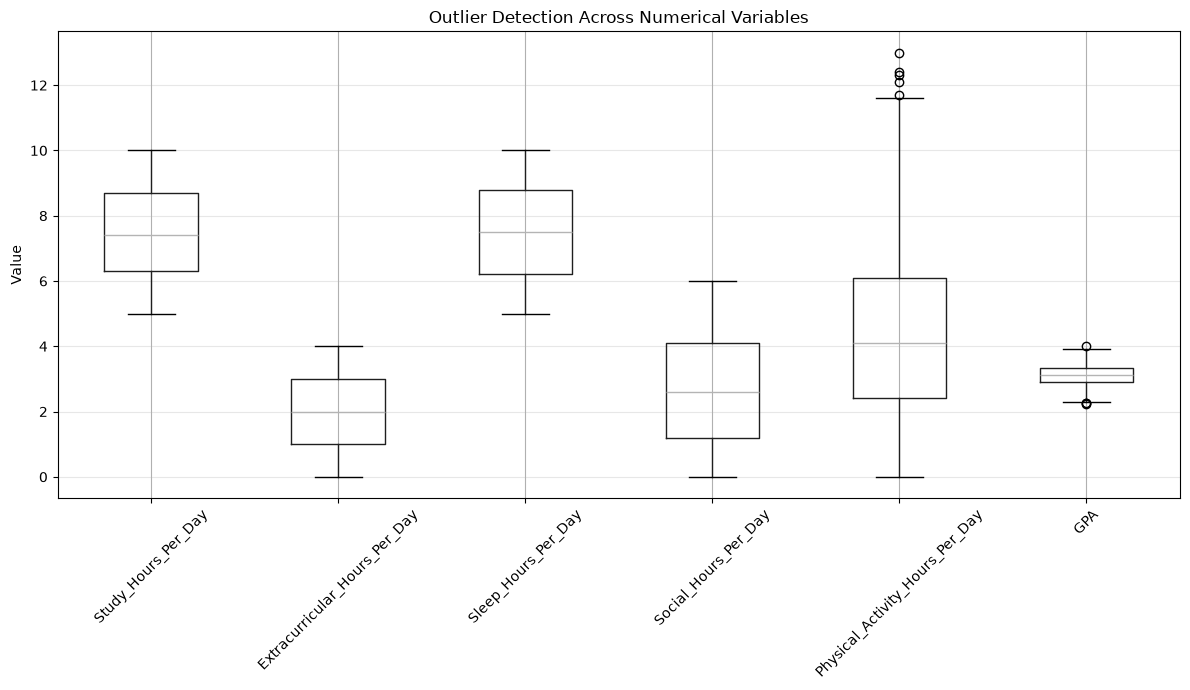

In [30]:
# Step 18B: Visualize distributions using box plots

plt.figure(figsize=(12, 7))

df[numerical_analysis_cols].boxplot()

plt.title("Outlier Detection Across Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Outlier Analysis — Findings and Interpretation

The IQR method identified a small number of potential outliers in the numerical analysis variables.

Study_Hours_Per_Day, Extracurricular_Hours_Per_Day, Sleep_Hours_Per_Day, and Social_Hours_Per_Day have no observations outside their IQR-based boundaries.

Physical_Activity_Hours_Per_Day has 5 potential outliers, representing 0.25% of the 2,000 observations. These observations correspond to unusually high physical activity values but remain plausible within the context of student lifestyle behavior.

GPA has 4 potential outliers, representing 0.20% of the observations. These observations represent unusually low or high GPA values according to the IQR rule, but they remain within the valid GPA range of 0 to 4 and therefore are not automatically considered data errors.

Overall, the number of potential outliers is very small. The detected observations appear to represent legitimate variation rather than obvious data-entry errors.

Therefore, no observations are removed or modified as part of the outlier analysis. Retaining these observations preserves the original variability of the dataset and avoids introducing unnecessary bias.

Student_ID was excluded from outlier analysis because it is an identifier rather than an analytical variable.

### Outlier Treatment Decision

Based on the IQR analysis and visual inspection of the box plots, the detected outliers are retained in the dataset.

The outlier analysis does not provide sufficient evidence that these observations are erroneous. The unusual Physical_Activity_Hours_Per_Day and GPA values are within plausible ranges for the variables.

No rows are deleted, no values are capped or transformed, and the cleaned dataset remains unchanged.

This decision ensures that the subsequent statistical analysis represents the complete set of valid student observations.

In [31]:
# Step 18C: Verify that no observations were removed

print("Dataset shape after outlier analysis:", df.shape)
print("Number of observations:", len(df))

print("\nOutlier treatment decision:")
print("No observations were removed or modified.")

Dataset shape after outlier analysis: (2000, 8)
Number of observations: 2000

Outlier treatment decision:
No observations were removed or modified.


# 19. Overall EDA Findings and Insights

This section consolidates the major findings obtained from the data understanding, cleaning, univariate, bivariate, multivariate, and outlier analyses.

The objective is to identify the most important patterns in student lifestyle behavior, stress levels, and academic performance.

## 19A. Key Numerical Findings

The exploratory analysis produced several important findings regarding student lifestyle variables and academic performance.

1. **Study Hours and GPA:** Study_Hours_Per_Day has the strongest positive relationship with GPA, with a Pearson correlation of **0.7345**. This indicates a strong positive association between daily study time and academic performance in the dataset.

2. **Physical Activity and GPA:** Physical_Activity_Hours_Per_Day has a negative association with GPA (r = **-0.3412**). This relationship is weaker than the study-hours relationship and should be interpreted as an association rather than a causal effect.

3. **Other Lifestyle Variables and GPA:** Extracurricular_Hours_Per_Day (r = -0.0322), Sleep_Hours_Per_Day (r = -0.0043), and Social_Hours_Per_Day (r = -0.0857) show very weak linear relationships with GPA.

4. **Study Hours and Physical Activity:** These variables show a moderate negative correlation (r = **-0.4881**), suggesting that higher reported study time is associated with lower reported physical activity time in this dataset.

5. **Other Lifestyle Relationships:** Several negative relationships exist among the lifestyle variables, particularly those involving Physical_Activity_Hours_Per_Day. These relationships provide useful context for understanding how students allocate their daily time.

Overall, the analysis indicates that study time is the lifestyle variable most strongly associated with academic performance among the variables examined.

## 19B. Key Stress-Level Findings

The dataset contains three stress categories: Low, Moderate, and High.

The distribution is imbalanced, with the High stress category representing the largest group of students, followed by Moderate and Low stress levels.

The analysis of lifestyle variables across stress groups revealed several differences:

- **Study_Hours_Per_Day** increases across the Low, Moderate, and High stress groups.
- **Sleep_Hours_Per_Day** decreases as stress level increases.
- **Social_Hours_Per_Day** also shows a decreasing pattern across stress levels.
- **Physical_Activity_Hours_Per_Day** decreases as stress level increases.
- **Extracurricular_Hours_Per_Day** shows very similar values across the three stress groups.

The Kruskal-Wallis analysis indicated statistically significant differences across stress groups for several lifestyle variables, while Extracurricular_Hours_Per_Day did not show a statistically significant difference.

The GPA analysis also showed a clear difference across stress groups. Mean GPA increased from the Low stress group to the Moderate and High stress groups.

The Kruskal-Wallis test for GPA produced an H-statistic of **620.6702** with a p-value below 0.05, indicating a statistically significant difference in GPA distributions across the three stress categories.

These results describe differences between groups and do not establish that stress directly causes changes in GPA or lifestyle behavior.

## 19C. Outlier Findings

The IQR-based outlier analysis identified very few potential outliers.

- Study_Hours_Per_Day: 0 outliers
- Extracurricular_Hours_Per_Day: 0 outliers
- Sleep_Hours_Per_Day: 0 outliers
- Social_Hours_Per_Day: 0 outliers
- Physical_Activity_Hours_Per_Day: 5 outliers (0.25%)
- GPA: 4 outliers (0.20%)

The detected observations were considered plausible values rather than obvious data-entry errors.

Therefore, no observations were removed, capped, or modified during outlier treatment.

The final analytical dataset continues to contain **2,000 observations and 8 columns**.

## 19D. Overall EDA Conclusions

The exploratory data analysis provides several important insights into the relationship between student lifestyle patterns, stress levels, and academic performance.

The strongest finding is the positive association between study time and GPA. Students reporting higher study hours generally show higher GPA values, making study time the most prominent lifestyle variable associated with academic performance in this dataset.

Stress levels are also associated with differences in lifestyle patterns and GPA. Students in different stress categories show distinct distributions of study time, sleep, social activity, physical activity, and GPA.

The analysis also indicates that higher stress levels are associated with higher reported study hours but lower reported sleep, social, and physical activity hours. However, these findings represent patterns in observational data and should not be interpreted as causal relationships.

The dataset was found to be of good quality, with no missing values, duplicate records, or invalid values requiring correction. Only a very small number of statistical outliers were identified, and they were retained because they appeared to represent plausible observations.

Overall, the EDA suggests that **study behavior, lifestyle allocation, stress level, and academic performance are interconnected**, with study hours showing the strongest direct linear association with GPA among the variables examined.

These findings provide a foundation for further statistical analysis or predictive modeling, if required.

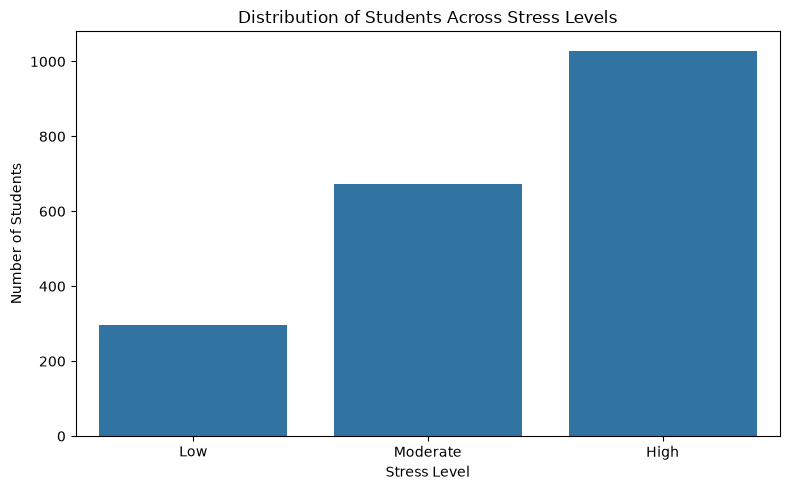

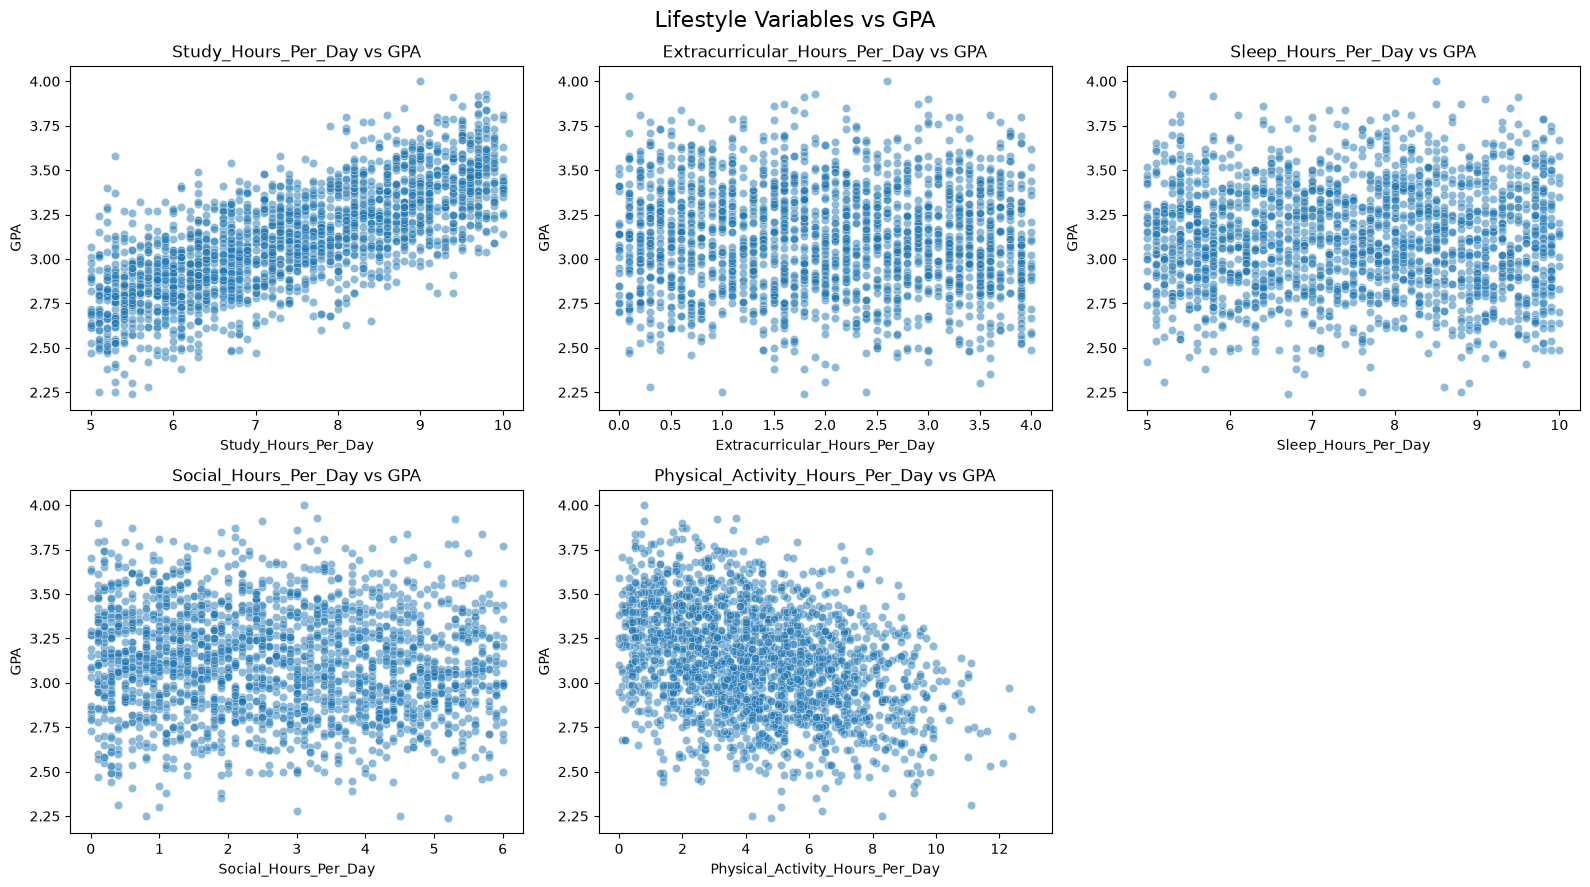

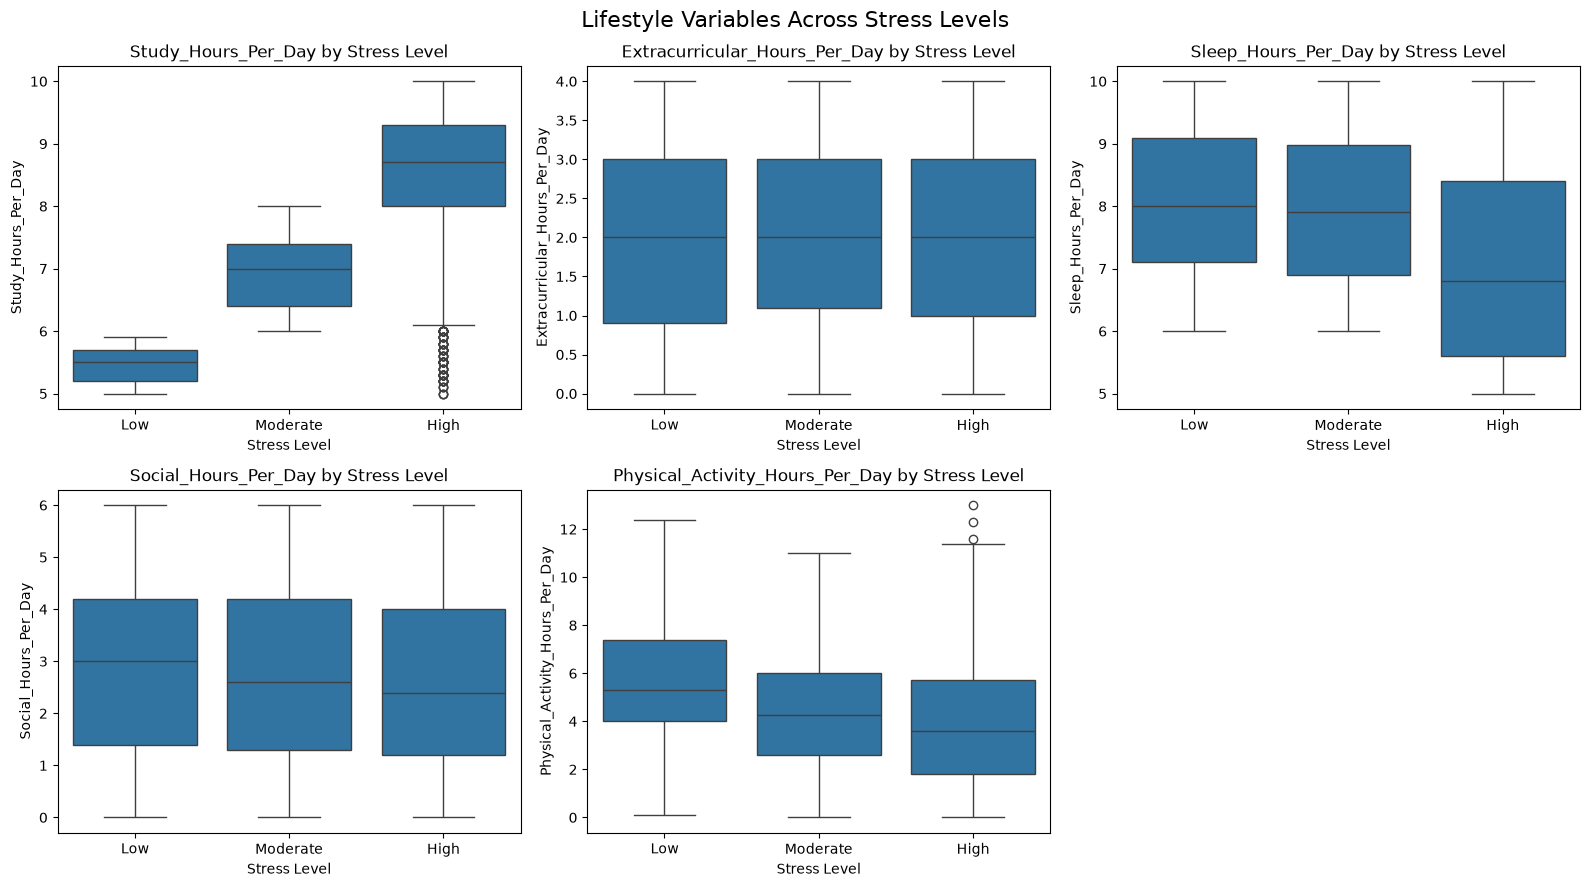

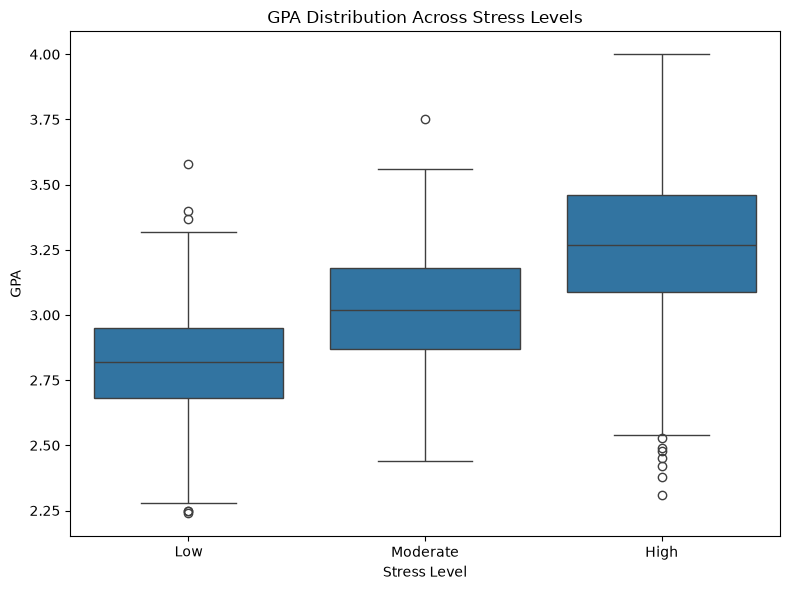

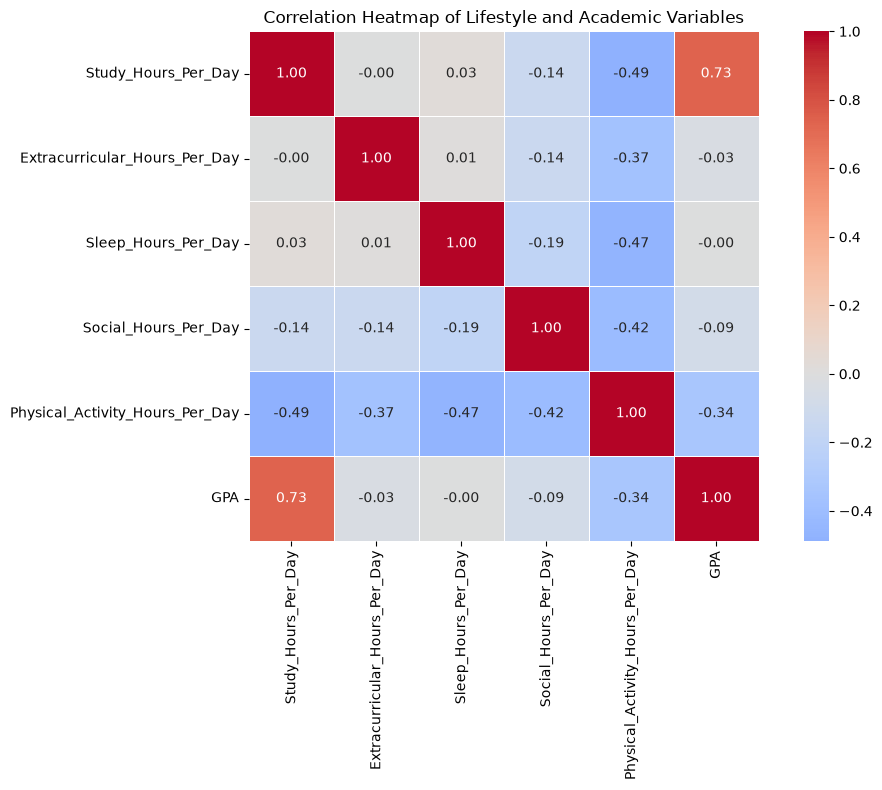

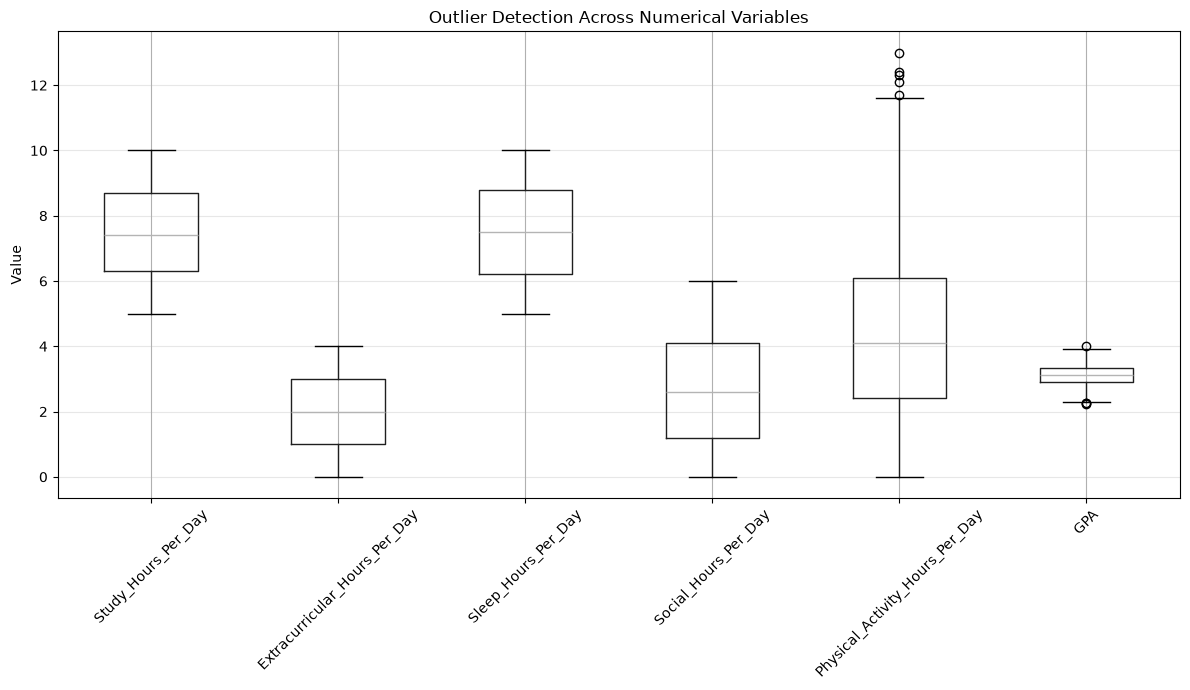

EDA figures exported successfully.

Files saved in: ../outputs/figures

Exported figures:
- correlation_heatmap.png
- gpa_across_stress_levels.png
- lifestyle_variables_vs_gpa.png
- lifestyle_variables_vs_stress.png
- outlier_detection.png
- stress_level_distribution.png


In [32]:
# STEP 21H: Export Important EDA Figures
# This cell saves important visualizations without changing the dataset.

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figures directory if it does not already exist
figures_dir = "../outputs/figures"
os.makedirs(figures_dir, exist_ok=True)


# ---------------------------------------------------------
# 1. Stress Level Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

stress_counts = df['Stress_Level'].value_counts().reindex(
    ['Low', 'Moderate', 'High']
)

sns.barplot(
    x=stress_counts.index,
    y=stress_counts.values
)

plt.title("Distribution of Students Across Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "stress_level_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 2. Lifestyle Variables vs GPA
# ---------------------------------------------------------

lifestyle_cols = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, lifestyle_cols):
    sns.scatterplot(
        data=df,
        x=col,
        y='GPA',
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f"{col} vs GPA")

# Hide the unused sixth subplot
axes.flat[-1].axis("off")

fig.suptitle("Lifestyle Variables vs GPA", fontsize=16)

plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "lifestyle_variables_vs_gpa.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 3. Lifestyle Variables Across Stress Levels
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, lifestyle_cols):
    sns.boxplot(
        data=df,
        x='Stress_Level',
        y=col,
        order=['Low', 'Moderate', 'High'],
        ax=ax
    )
    ax.set_title(f"{col} by Stress Level")
    ax.set_xlabel("Stress Level")
    ax.set_ylabel(col)

axes.flat[-1].axis("off")

fig.suptitle(
    "Lifestyle Variables Across Stress Levels",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "lifestyle_variables_vs_stress.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 4. GPA Across Stress Levels
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Stress_Level',
    y='GPA',
    order=['Low', 'Moderate', 'High']
)

plt.title("GPA Distribution Across Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("GPA")
plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "gpa_across_stress_levels.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 5. Correlation Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Lifestyle and Academic Variables")
plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 6. Outlier Detection Box Plots
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

df[numerical_analysis_cols].boxplot()

plt.title("Outlier Detection Across Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "outlier_detection.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# Final confirmation
# ---------------------------------------------------------

print("EDA figures exported successfully.")
print("\nFiles saved in:", figures_dir)

print("\nExported figures:")
for filename in sorted(os.listdir(figures_dir)):
    print("-", filename)